<div style="text-align: center;">
  <h1><b>🧠 Tumor Segmentation Module (U-Net) 🎯</b></h1>
  <p><i>Final Stage in an Intelligent Pipeline for Tumor Detection & Analysis</i></p>
</div>

<p align="center">
  <img src="download.jpg" width="800"/>
</p>

# **Our Details**

### ‎‧₊˚✿[My Name]✿˚ : **Mohamed Reda Ramadan Khamis**
### ‎‧₊˚✿[Phone Number]✿˚: **01554725661**

In [2]:
!pip install opendatasets

In [5]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/mateuszbuda/lgg-mri-segmentation", data_dir=".")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: Mohamed Reda
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/mateuszbuda/lgg-mri-segmentation


100%|██████████| 714M/714M [00:46<00:00, 16.1MB/s]


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")
import os
import glob
from PIL import Image
import cv2

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix , classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

np.random.seed(42)

In [7]:
DATA_DIR   = "/content/lgg-mri-segmentation/kaggle_3m"
IMG_SIZE   = (256, 256)
BATCH_SIZE = 16
SEED       = 42


def build_dataframe(data_dir: str) -> pd.DataFrame:
    image_paths = sorted([
        p for p in glob.glob(os.path.join(data_dir, "**/*.tif"), recursive=True)
        if "_mask" not in p
    ])

    mask_paths = [p.replace(".tif", "_mask.tif") for p in image_paths]

    missing = [m for m in mask_paths if not os.path.exists(m)]
    if missing:
        raise FileNotFoundError(f"{len(missing)} masks not found. First: {missing[0]}")

    labels = []
    for mask_path in mask_paths:
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        labels.append(1 if mask.max() > 0 else 0)

    df = pd.DataFrame({
        "image"     : image_paths,
        "mask"      : mask_paths,
        "has_tumor" : labels
    })

    print(f"Total pairs found : {len(df)}")
    print(f"With tumor        : {df['has_tumor'].sum()} ({df['has_tumor'].mean()*100:.1f}%)")
    print(f"Without tumor     : {(df['has_tumor']==0).sum()} ({(df['has_tumor']==0).mean()*100:.1f}%)")

    return df

In [8]:
df = build_dataframe(DATA_DIR)
df

Total pairs found : 3929
With tumor        : 1373 (34.9%)
Without tumor     : 2556 (65.1%)


,image,mask,has_tumor
0,/content/lgg-mri-segmentation/kaggle_3m/TCGA_C...,/content/lgg-mri-segmentation/kaggle_3m/TCGA_C...,0
1,/content/lgg-mri-segmentation/kaggle_3m/TCGA_C...,/content/lgg-mri-segmentation/kaggle_3m/TCGA_C...,0
2,/content/lgg-mri-segmentation/kaggle_3m/TCGA_C...,/content/lgg-mri-segmentation/kaggle_3m/TCGA_C...,1
3,/content/lgg-mri-segmentation/kaggle_3m/TCGA_C...,/content/lgg-mri-segmentation/kaggle_3m/TCGA_C...,1
4,/content/lgg-mri-segmentation/kaggle_3m/TCGA_C...,/content/lgg-mri-segmentation/kaggle_3m/TCGA_C...,1
...,...,...,...
3924,/content/lgg-mri-segmentation/kaggle_3m/TCGA_H...,/content/lgg-mri-segmentation/kaggle_3m/TCGA_H...,0
3925,/content/lgg-mri-segmentation/kaggle_3m/TCGA_H...,/content/lgg-mri-segmentation/kaggle_3m/TCGA_H...,0
3926,/content/lgg-mri-segmentation/kaggle_3m/TCGA_H...,/content/lgg-mri-segmentation/kaggle_3m/TCGA_H...,0
3927,/content/lgg-mri-segmentation/kaggle_3m/TCGA_H...,/content/lgg-mri-segmentation/kaggle_3m/TCGA_H...,0


In [9]:
def split_data(df: pd.DataFrame):
    train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df["has_tumor"], random_state=SEED)
    val_df, test_df   = train_test_split(temp_df, test_size=0.5, stratify=temp_df["has_tumor"], random_state=SEED)

    print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
    return (
        train_df.reset_index(drop=True),
        val_df.reset_index(drop=True),
        test_df.reset_index(drop=True)
    )

In [10]:
def load_sample(img_path, msk_path):

    def _load(img_path, msk_path):
        img_path = img_path.numpy().decode("utf-8")
        msk_path = msk_path.numpy().decode("utf-8")

        img = np.array(
            Image.open(img_path).convert("RGB").resize(IMG_SIZE),
            dtype=np.float32
        )
        img = img / 255.0

        msk = np.array(
            Image.open(msk_path).convert("L").resize(IMG_SIZE),
            dtype=np.float32
        )
        msk = msk / 255.0
        msk = (msk > 0.5).astype(np.float32)
        msk = np.expand_dims(msk, axis=-1)

        return img, msk

    img, msk = tf.py_function(_load, [img_path, msk_path], [tf.float32, tf.float32])

    img.set_shape([IMG_SIZE[0], IMG_SIZE[1], 3])
    msk.set_shape([IMG_SIZE[0], IMG_SIZE[1], 1])

    return img, msk

In [11]:
def augment(img, msk):
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_left_right(img)
        msk = tf.image.flip_left_right(msk)

    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_up_down(img)
        msk = tf.image.flip_up_down(msk)

    img = tf.image.random_brightness(img, max_delta=0.1)
    img = tf.clip_by_value(img, 0.0, 1.0)

    return img, msk


In [12]:
def build_dataset(df: pd.DataFrame, augment_data=False) -> tf.data.Dataset:
    img_paths = df["image"].values
    msk_paths = df["mask"].values

    dataset = tf.data.Dataset.from_tensor_slices((img_paths, msk_paths))
    dataset = dataset.map(load_sample, num_parallel_calls=tf.data.AUTOTUNE)

    if augment_data:
        dataset = dataset.map(augment, num_parallel_calls=tf.data.AUTOTUNE)

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

In [13]:
train_df, val_df, test_df = split_data(df)

train_dataset = build_dataset(train_df, augment_data=True)
val_dataset   = build_dataset(val_df,   augment_data=False)
test_dataset  = build_dataset(test_df,  augment_data=False)

Train: 3143 | Val: 393 | Test: 393


In [14]:
import tensorflow as tf
from tensorflow.keras import layers, Model


def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    return x

def encoder_block(x, filters):
    skip = conv_block(x, filters)          # clean, no dropout anywhere
    pool = layers.MaxPooling2D(2)(skip)    # clean pool
    return skip, pool

def decoder_block(x, skip, filters, dropout_rate=0.0):
    x = layers.UpSampling2D(2)(x)
    x = layers.Concatenate()([x, skip])
    x = conv_block(x, filters)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    return x

def build_unet(input_shape=(256, 256, 3)):
    inputs = layers.Input(shape=input_shape)

    # Encoder — no dropout
    s1, p1 = encoder_block(inputs, 64)
    s2, p2 = encoder_block(p1,     128)
    s3, p3 = encoder_block(p2,     256)
    s4, p4 = encoder_block(p3,     512)

    # Bottleneck — dropout here only
    b = conv_block(p4, 1024)
    b = layers.Dropout(0.5)(b)

    # Decoder — light dropout
    d1 = decoder_block(b,  s4, 512, 0.2)
    d2 = decoder_block(d1, s3, 256, 0.2)
    d3 = decoder_block(d2, s2, 128, 0.1)
    d4 = decoder_block(d3, s1, 64,  0.0)   # last decoder no dropout

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(d4)
    return Model(inputs, outputs, name="U-Net")



model = build_unet(input_shape=(256, 256, 3))
model.summary()

Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_4[0][0]  

 Total params: 31,402,497 (119.79 MB)

 Trainable params: 31,390,721 (119.75 MB)

 Non-trainable params: 11,776 (46.00 KB)

In [15]:
from tensorflow.keras import backend as K


def iou_coef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)

    intersection = K.sum(y_true * y_pred)
    union        = K.sum(y_true) + K.sum(y_pred) - intersection

    return (intersection + smooth) / (union + smooth)


def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)

    intersection = K.sum(y_true * y_pred)

    return (2.0 * intersection + smooth) / (K.sum(y_true) + K.sum(y_pred) + smooth)


def dice_loss(y_true, y_pred, smooth=1e-6):
    intersection = tf.reduce_sum(y_true * y_pred)
    return 1 - (2. * intersection + smooth) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth)


def bce_dice_loss(y_true, y_pred):
    return 0.7 * tf.keras.losses.binary_crossentropy(y_true, y_pred) + 0.3 * dice_loss(y_true, y_pred)


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=bce_dice_loss,
    metrics=["accuracy", iou_coef, dice_coef]
)

In [16]:
early_stop = EarlyStopping(
    monitor="val_dice_coef",
    mode="max",
    patience=12,
    restore_best_weights=True,
    verbose=1
)


reduce_lr = ReduceLROnPlateau(
    monitor="val_dice_coef",
    mode="max",
    factor=0.5,
    patience=4,
    min_lr=1e-7,
    verbose=1
)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=100,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 430s 2s/step - accuracy: 0.9660 - dice_coef: 0.4574 - iou_coef: 0.3198 - loss: 0.4246 - val_accuracy: 0.9905 - val_dice_coef: 1.2139e-10 - val_iou_coef: 1.2139e-10 - val_loss: 0.4150 - learning_rate: 1.0000e-04
Epoch 2/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 238s 1s/step - accuracy: 0.9905 - dice_coef: 0.5716 - iou_coef: 0.4198 - loss: 0.3318 - val_accuracy: 0.7567 - val_dice_coef: 0.0678 - val_iou_coef: 0.0353 - val_loss: 1.8171 - learning_rate: 1.0000e-04
Epoch 3/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 229s 1s/step - accuracy: 0.9894 - dice_coef: 0.5437 - iou_coef: 0.3953 - loss: 0.3134 - val_accuracy: 0.9941 - val_dice_coef: 0.6346 - val_iou_coef: 0.4881 - val_loss: 0.2994 - learning_rate: 1.0000e-04
Epoch 4/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 228s 1s/step - accuracy: 0.9920 - dice_coef: 0.6311 - iou_coef: 0.4812 - loss: 0.2695 - val_accuracy: 0.9894 - val_dice_coef: 0.5583 - val_iou_coef: 0.4053 - val_loss: 0.2731 - learning_rate: 1.0000e-04
Epoch 5/100
197/

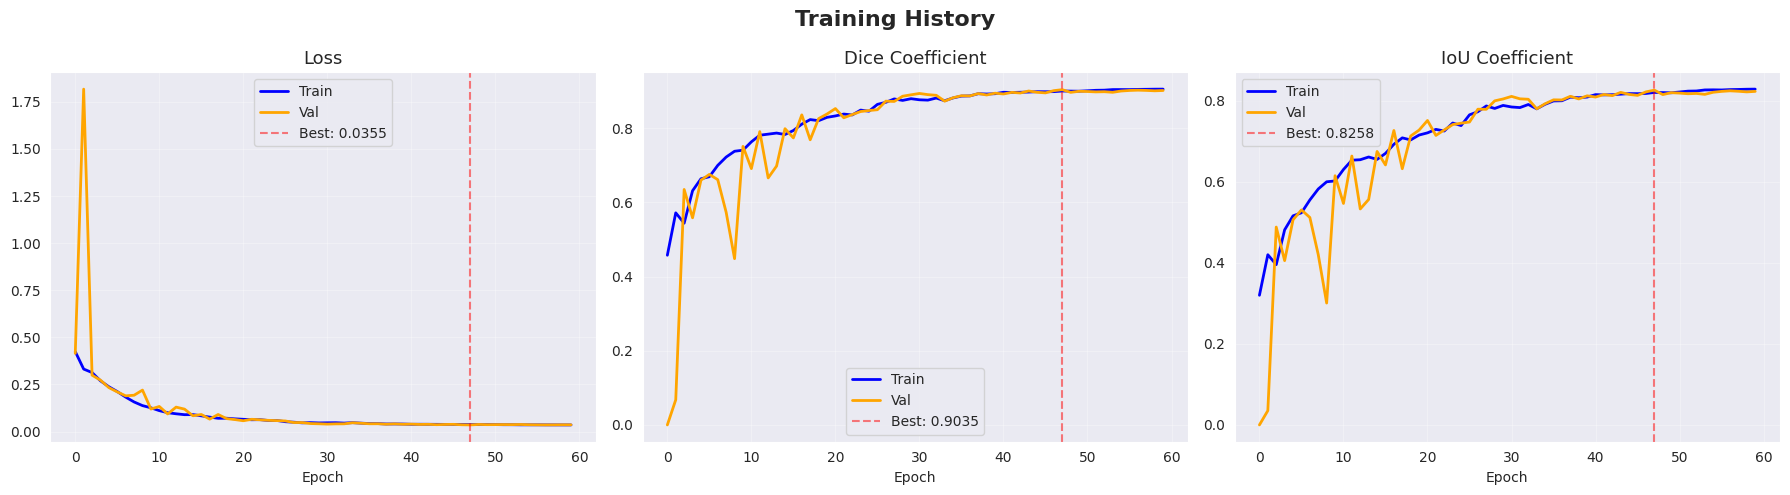

In [17]:
def plot_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Training History", fontsize=16, fontweight="bold")

    metrics = [
        ("loss",      "val_loss",      "Loss"),
        ("dice_coef", "val_dice_coef", "Dice Coefficient"),
        ("iou_coef",  "val_iou_coef",  "IoU Coefficient"),
    ]

    for ax, (train_m, val_m, title) in zip(axes, metrics):
        ax.plot(history.history[train_m], label="Train", color="blue",   linewidth=2)
        ax.plot(history.history[val_m],   label="Val",   color="orange", linewidth=2)
        ax.set_title(title, fontsize=13)
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(True, alpha=0.3)

        # Mark best epoch
        if "loss" in train_m:
            best_epoch = np.argmin(history.history[val_m])
        else:
            best_epoch = np.argmax(history.history[val_m])
        best_val = history.history[val_m][best_epoch]
        ax.axvline(x=best_epoch, color="red", linestyle="--", alpha=0.5, label=f"Best: {best_val:.4f}")
        ax.legend()

    plt.tight_layout()
    plt.savefig("training_history.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_history(history)

In [18]:
print("EVALUATION ON TEST SET")

results = model.evaluate(test_dataset, verbose=1)
metrics_names = model.metrics_names

for name, value in zip(metrics_names, results):
    print(f"{name:20s} → {value:.4f}")

EVALUATION ON TEST SET
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 440ms/step - accuracy: 0.9978 - dice_coef: 0.8676 - iou_coef: 0.7732 - loss: 0.0484
loss                 → 0.0484
compile_metrics      → 0.9978


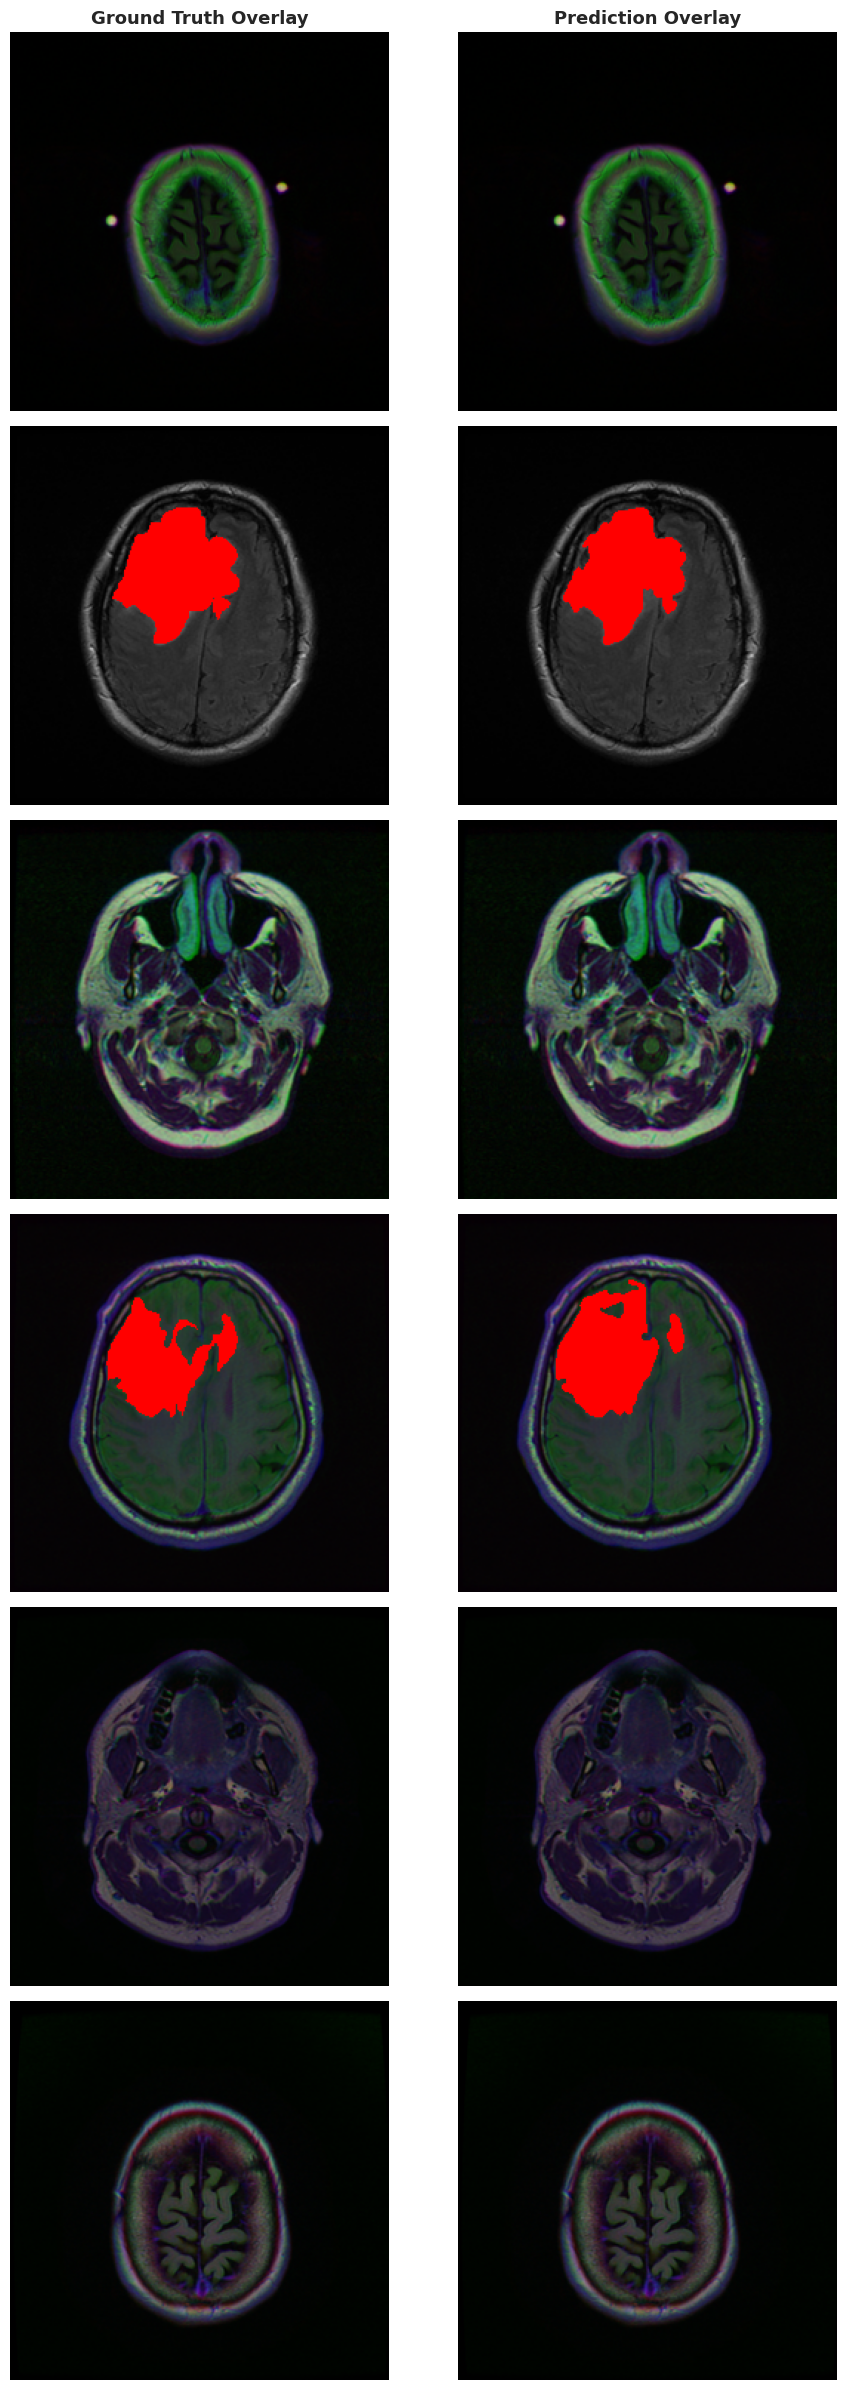

In [19]:
def visualize_overlay(model, dataset, num_samples=6):
    """Shows predicted mask overlaid on original MRI in red"""
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, num_samples * 4))

    axes[0][0].set_title("Ground Truth Overlay", fontsize=13, fontweight="bold")
    axes[0][1].set_title("Prediction Overlay",   fontsize=13, fontweight="bold")

    for imgs, masks in dataset.take(6):
        imgs  = imgs.numpy()
        masks = masks.numpy()
        preds = model.predict(imgs, verbose=0)
        preds = (preds > 0.5).astype(np.float32)

        for i in range(min(num_samples, len(imgs))):
            img  = imgs[i].copy()
            mask = masks[i, :, :, 0]
            pred = preds[i, :, :, 0]

            # Ground truth overlay
            gt_overlay = img.copy()
            gt_overlay[mask == 1] = [1.0, 0.0, 0.0]

            # Prediction overlay
            pred_overlay = img.copy()
            pred_overlay[pred == 1] = [1.0, 0.0, 0.0]

            axes[i][0].imshow(gt_overlay)
            axes[i][0].axis("off")

            axes[i][1].imshow(pred_overlay)
            axes[i][1].axis("off")

    plt.tight_layout()
    plt.show()


visualize_overlay(model, test_dataset, num_samples=6)

In [22]:
model.save('unet_final1.keras')
print("Model is Saved")

Model is Saved
